In [6]:
import pytometry as pk

In [7]:
fcs_path = 'cytof/fcs/184A1andUACC3199/_e270_184A1_A_0_egf_singlets_egf.fcs.fcs'
sample = pk.io.read_fcs(fcs_path)

/opt/homebrew/Cellar/python@3.13/3.13.9_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [14]:
import numpy as np
import pandas as pd
import synapseclient
import matplotlib.pyplot as plt
syn = synapseclient.Synapse()
syn.login()


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.10.0) is available. Your version (4.9.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.10.0 release notes

https://python-docs.synapse.org/news/


Welcome, Fabian Froehlich!



In [15]:
df_sc = pd.read_csv(syn.get("syn20613594").path)
df_sc_2656 = df_sc[df_sc['fileID']==2656]

[syn20613594:184A1.csv]: Found existing file at /Users/frohlif/.synapseCache/703/42210703/184A1.csv, skipping download.


In [16]:
def scalar_affine_fit(A, B):
    # Fit B = scale * A + shift
    # ymax = scale * xmax + shift
    # ymin = scale * xmin + shift
    scale = (B.max() - B.min()) / (A.max() - A.min())
    shift = B.min() - scale * A.min()
    return scale, shift

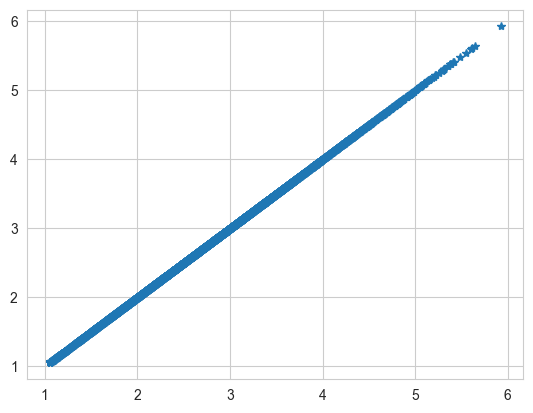

In [19]:
x_transformed = np.asinh((sample.T['163Dy_p-p90RSK'].X[0,:] + 1))
scale, shift = scalar_affine_fit(x_transformed, df_sc_2656['p.p90RSK'].values)
x_transformed = x_transformed * scale + shift
plt.plot(np.sort(df_sc_2656['p.p90RSK'].values), np.sort(x_transformed), '*')
